# 聚类算法（K-Means Clustering）

本 Notebook 以 K-Means 为核心，覆盖从基础演示到生产级实战的完整流程，包括数据标准化、肘部法选 k、客户行为分组等。

## 一、K-Means 基础示例（模拟数据集）

In [1]:
# =========================================
# 1. 导入必要的库
# =========================================

# KMeans: sklearn 提供的 K-Means 聚类算法类
from sklearn.cluster import KMeans

# make_blobs: 生成用于聚类测试的模拟高斯分布数据集
from sklearn.datasets import make_blobs

# StandardScaler: 数据标准化处理器（零均值单位方差，消除特征量纲差异）
from sklearn.preprocessing import StandardScaler

# silhouette_score: 轮廓系数评估指标，衡量聚类质量，范围 [-1, 1]，越大越好
from sklearn.metrics import silhouette_score

# calinski_harabasz_score: CH 指数，衡量簇间分离度与簇内紧凑度，值越大越好
from sklearn.metrics import calinski_harabasz_score

# matplotlib.pyplot: 绘图库，用于可视化聚类结果和评估曲线
import matplotlib.pyplot as plt


# =========================================
# 2. 生成模拟数据集
# =========================================

# make_blobs 参数说明：
#   n_samples   (int)  : 生成的样本总数，此处为 300 个数据点
#   n_features  (int)  : 每个样本的特征维度，此处为 2 维（便于二维可视化）
#   centers     (int)  : 真实簇的数量，此处为 3 个簇
#   cluster_std (float): 每个簇的标准差，控制簇内分散程度，越大越分散
#   random_state(int)  : 随机种子，保证每次运行结果一致、可复现
# 返回值：
#   X (ndarray, shape=[300, 2]): 生成的特征矩阵，每行为一个样本的两个特征值
#   _ (ndarray, shape=[300,]) : 真实簇标签（无监督聚类通常不使用，用 _ 忽略）
X, _ = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=1.0, random_state=42)


## 二、数据标准化与模型训练

当 k=3 时：
SSE: 18.2632
SC : 0.8482


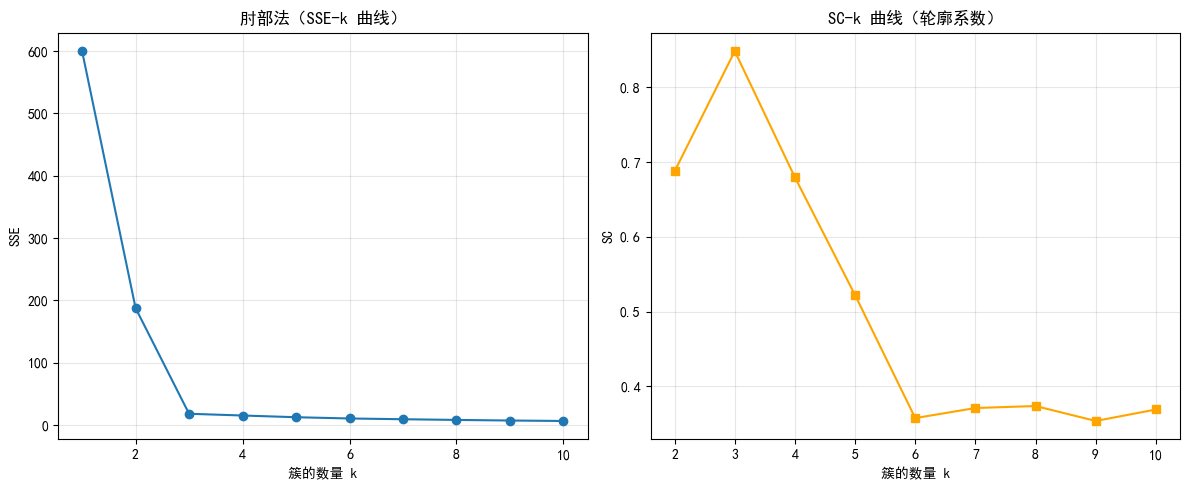

In [2]:
# =========================================
# 3. 设置中文字体（matplotlib 全局配置）
# =========================================

# 字体优先级：SimHei（黑体）> Microsoft YaHei > Arial Unicode MS
# 解决 matplotlib 默认不支持中文字符导致的方块乱码问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']

# 将 axes.unicode_minus 设为 False，解决坐标轴负号显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

# =========================================
# 4. 数据标准化
# =========================================

# 创建标准化器实例，使各特征均值为 0、标准差为 1，消除量纲差异
scaler = StandardScaler()

# fit_transform(X):
#   参数: X (ndarray, shape=[n_samples, n_features])，原始特征矩阵
#   返回: X_scaled (ndarray, shape=[n_samples, n_features])，标准化后的特征矩阵
X_scaled = scaler.fit_transform(X)

# =========================================
# 5. 以 k=3 为例训练一次聚类，输出 SSE 与 SC 评估指标
# =========================================

# 设定簇的数量 k=3（与 make_blobs 生成时的 centers=3 对应，用于效果验证）
k = 3

# 创建 KMeans 模型
# 参数:
#   n_clusters   (int): 聚类簇的数量
#   random_state (int): 随机种子，确保初始化结果可复现
#   n_init       (int): 算法以不同随机初始化运行的次数，最终取 SSE 最小的那次
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# fit_predict(X_scaled): 训练模型并返回每个样本的簇标签
#   参数: X_scaled (ndarray, shape=[n_samples, n_features])，标准化后的特征矩阵
#   返回: labels (ndarray, shape=[n_samples,])，每个样本所属簇的索引（0 到 k-1）
labels = kmeans.fit_predict(X_scaled)

# inertia_: 模型属性，所有样本到其最近簇中心的距离平方和（SSE）
# SSE 越小代表簇内越紧凑，但随 k 增大必然下降，需结合肘部法判断最优 k
sse = kmeans.inertia_  # SSE（簇内平方和）

# silhouette_score(X, labels):
#   参数: X (ndarray) 标准化特征矩阵; labels (ndarray) 每个样本的簇标签
#   返回: sc (float)，所有样本轮廓系数的均值，范围 [-1, 1]
sc = silhouette_score(X_scaled, labels)  # SC（轮廓系数）

# 打印当前 k 下的评估结果
print(f'当 k={k} 时：')
print(f'SSE: {sse:.4f}')  # SSE 越小越好（簇内紧凑）
print(f'SC : {sc:.4f}')   # SC 越接近 1 越好（簇间分离、簇内紧凑）

# =========================================
# 6. 遍历不同 k 值，收集 SSE 与 SC（肘部法数据准备）
# =========================================

# 定义 k 的取值范围：1 到 10
k_values = range(1, 11)

sse_list = []  # 存储各 k 对应的 SSE 值（list[float]）
sc_list = []   # 存储各 k 对应的 SC 值（list[float | None]，k=1 时为 None）

for kk in k_values:
    # 用当前 kk 创建 KMeans 模型并训练
    km = KMeans(n_clusters=kk, random_state=42, n_init=10)

    # fit_predict: 训练并返回各样本的簇标签（ndarray, shape=[n_samples,]）
    y_pred = km.fit_predict(X_scaled)

    # 记录当前 kk 的 SSE（float）
    sse_list.append(km.inertia_)

    # 轮廓系数要求至少存在 2 个簇，k=1 时无意义，置为 None
    if kk >= 2:
        sc_list.append(silhouette_score(X_scaled, y_pred))
    else:
        sc_list.append(None)

# =========================================
# 7. 绘图：肘部法（SSE-k 曲线）与轮廓系数（SC-k 曲线）
# =========================================

# 创建 1 行 2 列子图画布，figsize=(12, 5) 表示宽 12 英寸、高 5 英寸
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- 左图：肘部法（SSE-k 曲线） ---
# SSE 曲线在某个 k 处出现明显弯折（肘部），该 k 即为推荐的最佳簇数
axes[0].plot(list(k_values), sse_list, marker='o')  # 'o' 在数据点处画圆点标记
axes[0].set_title('肘部法（SSE-k 曲线）')   # 子图标题
axes[0].set_xlabel('簇的数量 k')             # x 轴标签
axes[0].set_ylabel('SSE')                    # y 轴标签（簇内平方和）
axes[0].grid(True, alpha=0.3)               # 添加半透明网格线辅助读数

# --- 右图：轮廓系数（SC-k 曲线），k>=2 才有意义 ---
valid_k = list(k_values)[1:]   # 从 k=2 开始的 k 值列表（去除 k=1）
valid_sc = sc_list[1:]         # 对应的 SC 值列表（去除 k=1 的 None）

# 's' 表示方形标记；SC 越高表示聚类效果越好
axes[1].plot(valid_k, valid_sc, marker='s', color='orange')
axes[1].set_title('SC-k 曲线（轮廓系数）')  # 子图标题
axes[1].set_xlabel('簇的数量 k')             # x 轴标签
axes[1].set_ylabel('SC')                     # y 轴标签（轮廓系数）
axes[1].grid(True, alpha=0.3)               # 添加半透明网格线

# 自动调整子图之间的间距，防止坐标轴标签重叠
plt.tight_layout()
plt.show()  # 渲染并展示图表


## 三、实战：客户消费行为 K-Means 聚类

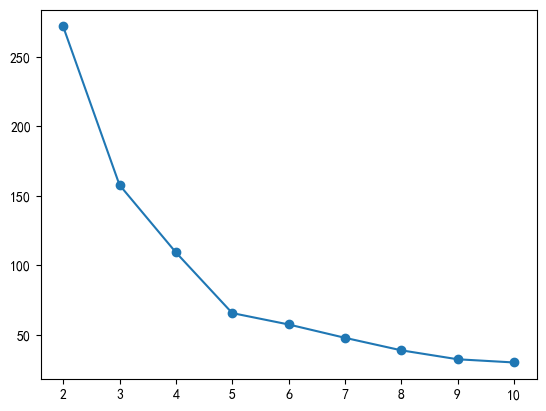

In [4]:
# 聚类案例：基于年收入和消费评分的客户细分

# =========================================
# 1. 导入必要的库
# =========================================

# numpy: 数值计算库，提供多维数组和高效矩阵运算
import numpy as np

# pandas: 数据处理库，提供 DataFrame 结构，便于读取和操作 CSV 表格
import pandas as pd

# matplotlib.pyplot: 绘图库，用于绘制评估曲线和聚类散点图
import matplotlib.pyplot as plt

# KMeans: K-Means 无监督聚类算法
from sklearn.cluster import KMeans

# StandardScaler: 数据标准化（零均值单位方差），消除特征量纲差异
from sklearn.preprocessing import StandardScaler

# silhouette_score: 轮廓系数，评估聚类效果，范围 [-1, 1]，越大越好
from sklearn.metrics import silhouette_score

# calinski_harabasz_score: CH 指数，评估聚类质量，值越大代表聚类越清晰
from sklearn.metrics import calinski_harabasz_score

# =========================================
# 2. 获取数据
# =========================================

# pd.read_csv: 读取 CSV 文件并解析为 DataFrame
#   参数: filepath_or_buffer (str)，CSV 文件的相对路径
#   返回: data (DataFrame)，包含客户信息的完整数据表
data = pd.read_csv('./data/customers.csv')

# head(): 显示 DataFrame 前 5 行，用于快速预览数据字段和格式
#   返回: DataFrame（前 5 行）
data.head()

# =========================================
# 3. 确定特征数据
# =========================================

# 使用「年收入（千美元）」和「消费评分（1-100）」两列作为聚类特征
# data[[col1, col2]]: 从 DataFrame 中按列名选取多列，返回子 DataFrame
#   返回: X (DataFrame, shape=[n_samples, 2])，含两列特征的子表
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# =========================================
# 4. 数据标准化处理
# =========================================

# 创建标准化器，使年收入和消费评分处于同一量纲，避免量纲大的特征主导聚类
scaler = StandardScaler()

# fit_transform(X): 先拟合（计算均值/标准差）再对 X 进行标准化变换
#   参数: X (DataFrame/ndarray, shape=[n_samples, 2])
#   返回: X (ndarray, shape=[n_samples, 2])，标准化后的数值矩阵（覆盖原变量 X）
X = scaler.fit_transform(X)

# =========================================
# 5. 肘部法：遍历不同 k 值，训练模型并收集 SSE 与 SC
# =========================================

SSE = []  # 存储各 k 对应的 SSE（簇内平方和，list[float]）
SC = []   # 存储各 k 对应的 SC（轮廓系数，list[float]）

# 遍历 k 从 2 到 10（k=1 时所有样本归为一类，无聚类意义）
for k in range(2, 11):
    # 创建 KMeans 模型，n_clusters 指定本次迭代使用的簇数量
    estimator = KMeans(n_clusters=k)

    # fit(X): 在标准化特征矩阵上训练聚类模型（无返回值）
    #   参数: X (ndarray, shape=[n_samples, 2])
    estimator.fit(X)

    # inertia_: 模型属性，当前 k 下所有样本到最近簇中心的距离平方和（SSE）
    SSE.append(estimator.inertia_)

    # silhouette_score(X, labels_): 计算当前 k 下的轮廓系数
    #   labels_ (ndarray, shape=[n_samples,]): 模型为每个样本分配的簇索引
    #   返回: float，所有样本轮廓系数的均值
    SC.append(silhouette_score(X, estimator.labels_))


# =========================================
# 6. 绘制评估曲线图
# =========================================

# --- 图 1：SSE 变化曲线（肘部法） ---
# range(2, 11): x 轴为 k 的取值范围（2 到 10）
# SSE: y 轴为对应的 SSE 值（list[float]）
# 'o-': 圆点连线风格，便于直观观察 SSE 拐点（肘部）
plt.plot(range(2, 11), SSE, 'o-')

# --- 图 2：SC 变化曲线（已注释，可按需取消注释单独展示） ---
# plt.plot(range(2, 11), SC, 'o-')        # 绘制轮廓系数随 k 的变化折线
# plt.title("the elbow method")            # 图表标题
# plt.xlabel("number of clusters")         # x 轴标签
# plt.ylabel("silhouette coefficient")     # y 轴标签
# plt.grid()                               # 显示网格线
# plt.show()                               # 渲染并展示图表


## 四、确定最优 k 值（肘部法则）

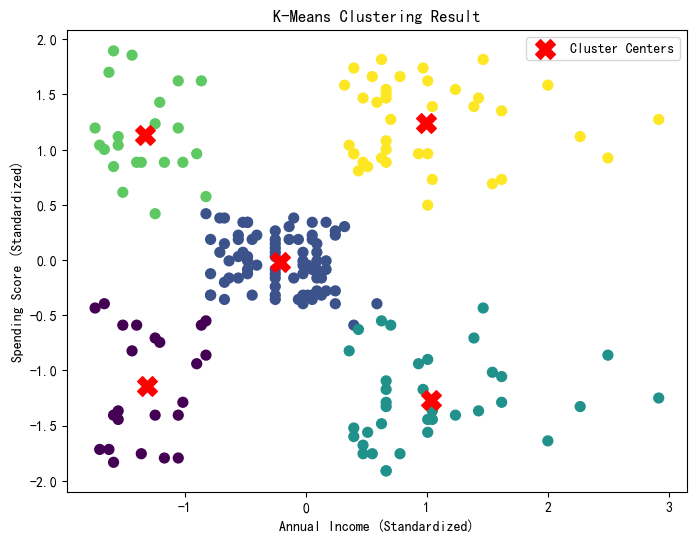

In [5]:
# =========================================
# 选择最优 k 并训练最终聚类模型
# =========================================

# 综合肘部法（SSE 拐点）和轮廓系数（SC 最大值）分析后，确定最佳簇数为 5
# best_k (int): 最终选定的聚类簇数量
best_k = 5

# 使用最优 k=5 创建 KMeans 聚类模型
kmeans = KMeans(n_clusters=best_k)

# fit_predict(X): 训练模型并为每个样本分配簇标签
#   参数: X (ndarray, shape=[n_samples, 2])，标准化后的特征矩阵
#   返回: labels (ndarray, shape=[n_samples,])，每个样本所属簇的索引（0 到 best_k-1）
labels = kmeans.fit_predict(X)

# =========================================
# 可视化聚类结果（二维散点图）
# =========================================

# 创建画布，figsize=(8, 6) 表示宽 8 英寸、高 6 英寸
plt.figure(figsize=(8, 6))

# plt.scatter: 绘制样本散点图，按簇标签着色
# 参数:
#   X[:, 0]        (ndarray): x 轴，标准化后的年收入特征（第 0 列）
#   X[:, 1]        (ndarray): y 轴，标准化后的消费评分特征（第 1 列）
#   c=labels       (ndarray): 根据簇标签映射颜色，不同簇显示不同颜色
#   cmap='viridis' (str)    : 使用 viridis 渐变色盘，视觉上易于区分不同簇
#   s=50           (float)  : 散点大小（单位：点^2），控制点的显示大小
# 返回: scatter (PathCollection)，散点图对象（可用于添加颜色条等扩展操作）
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)

# cluster_centers_: KMeans 模型属性，记录训练后各簇中心的坐标
#   类型: ndarray, shape=[n_clusters, n_features]，每行为一个簇中心的特征向量
centers = kmeans.cluster_centers_

# 用红色 'X' 标记绘制各簇中心，s=200 使其远大于普通点，便于视觉识别
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Cluster Centers')

plt.title("K-Means Clustering Result")          # 图表标题
plt.xlabel("Annual Income (Standardized)")       # x 轴标签：标准化后的年收入
plt.ylabel("Spending Score (Standardized)")      # y 轴标签：标准化后的消费评分
plt.legend()  # 显示图例，标注簇中心标记的含义
plt.show()    # 渲染并展示最终聚类散点图
